# 数据导入初步处理

## 导入函数库

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 字体设置
plt.rcParams['font.family'] = ['SimHei', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [29]:
# 设置当前的路径
current_path=os.getcwd()
dir_path=os.path.dirname(current_path)
data_path=dir_path+"\\data\\codon_usage.csv"
print("当前的数据文件的路径为：",data_path)

# 设定保存图片的路径
images_path=dir_path+"\\output\\images\\"

当前的数据文件的路径为： G:\JupyterNotebook\Internship\密码子项目\data\codon_usage.csv


In [30]:
codon_usage = pd.read_csv(data_path,low_memory=False)
df=codon_usage

# 查看前几行
df.head()

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [31]:
#查看数据基本信息
df.info()

# 查看缺失值
df.isnull().sum()

# 描述性统计
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13028 entries, 0 to 13027
Data columns (total 69 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kingdom      13028 non-null  object 
 1   DNAtype      13028 non-null  int64  
 2   SpeciesID    13028 non-null  int64  
 3   Ncodons      13028 non-null  int64  
 4   SpeciesName  13028 non-null  object 
 5   UUU          13028 non-null  object 
 6   UUC          13028 non-null  object 
 7   UUA          13028 non-null  float64
 8   UUG          13028 non-null  float64
 9   CUU          13028 non-null  float64
 10  CUC          13028 non-null  float64
 11  CUA          13028 non-null  float64
 12  CUG          13028 non-null  float64
 13  AUU          13028 non-null  float64
 14  AUC          13028 non-null  float64
 15  AUA          13028 non-null  float64
 16  AUG          13028 non-null  float64
 17  GUU          13028 non-null  float64
 18  GUC          13028 non-null  float64
 19  GUA 

,DNAtype,SpeciesID,Ncodons,UUA,UUG,CUU,CUC,CUA,CUG,AUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
count,13028.000000,13028.000000,1.302800e+04,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,...,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000
mean,0.367209,130451.105926,7.960576e+04,0.020637,0.014104,0.017820,0.018288,0.019044,0.018450,0.028352,...,0.005454,0.009929,0.006422,0.024178,0.021164,0.028290,0.021683,0.001645,0.000592,0.006178
std,0.688726,124787.086107,7.197010e+05,0.020709,0.009280,0.010586,0.014572,0.024250,0.016578,0.017507,...,0.006605,0.008574,0.006387,0.013828,0.013041,0.014342,0.015018,0.001834,0.000907,0.010344
min,0.000000,7.000000,1.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,28850.750000,1.602000e+03,0.005610,0.007108,0.010890,0.007830,0.005307,0.007180,0.016360,...,0.001220,0.001690,0.001170,0.012380,0.011860,0.017360,0.009710,0.000560,0.000000,0.000410
50%,0.000000,81971.500000,2.927500e+03,0.015260,0.013360,0.016130,0.014560,0.009685,0.012800,0.025475,...,0.003530,0.009270,0.004545,0.025420,0.019070,0.026085,0.020540,0.001380,0.000420,0.001130
75%,1.000000,222891.250000,9.120000e+03,0.029485,0.019810,0.022730,0.025112,0.017245,0.024315,0.038113,...,0.007150,0.015922,0.010250,0.034190,0.027690,0.036800,0.031122,0.002370,0.000830,0.002890
max,12.000000,465364.000000,4.066258e+07,0.151330,0.101190,0.089780,0.100350,0.163920,0.107370,0.154060,...,0.055540,0.098830,0.058430,0.185660,0.113840,0.144890,0.158550,0.045200,0.025610,0.106700


In [32]:
#查看列名
print("数据集中的所有特征",df.columns.tolist())

# 分类变量统计
print("生物所属的界",df['Kingdom'].value_counts())

print("DNA的类型",df['DNAtype'].value_counts())

数据集中的所有特征 ['Kingdom', 'DNAtype', 'SpeciesID', 'Ncodons', 'SpeciesName', 'UUU', 'UUC', 'UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG', 'AUU', 'AUC', 'AUA', 'AUG', 'GUU', 'GUC', 'GUA', 'GUG', 'GCU', 'GCC', 'GCA', 'GCG', 'CCU', 'CCC', 'CCA', 'CCG', 'UGG', 'GGU', 'GGC', 'GGA', 'GGG', 'UCU', 'UCC', 'UCA', 'UCG', 'AGU', 'AGC', 'ACU', 'ACC', 'ACA', 'ACG', 'UAU', 'UAC', 'CAA', 'CAG', 'AAU', 'AAC', 'UGU', 'UGC', 'CAU', 'CAC', 'AAA', 'AAG', 'CGU', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GAU', 'GAC', 'GAA', 'GAG', 'UAA', 'UAG', 'UGA']
生物所属的界 Kingdom
bct    2920
vrl    2832
pln    2523
vrt    2077
inv    1345
mam     572
phg     220
rod     215
pri     180
arc     126
plm      18
Name: count, dtype: int64
DNA的类型 DNAtype
0     9267
1     2899
2      816
4       31
12       5
5        2
3        2
11       2
9        2
6        1
7        1
Name: count, dtype: int64


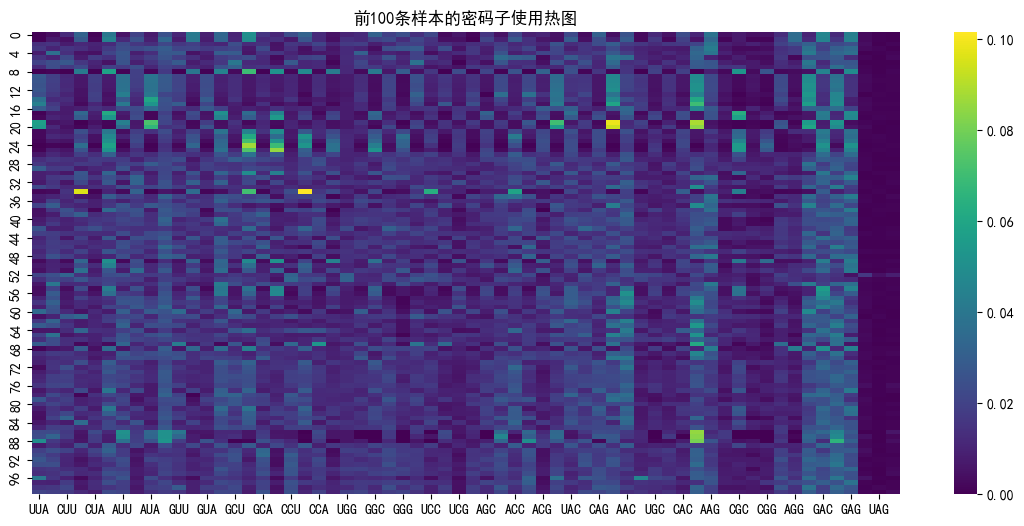

In [33]:
#密码子频率列
codon_columns = df.columns[7:]  # 从第8列起是密码子频率

# 绘制热图查看不同密码子的分布
plt.figure(figsize=(14, 6))
sns.heatmap(df[codon_columns].iloc[:100], cmap="viridis")
plt.title("前100条样本的密码子使用热图")
plt.savefig(images_path+"Codons_Usage_Heat_Maps.png")
plt.show()

## 计算密码子中的GC含量
每个样本中GC含量 = sum(每个密码子频率 * 3（碱基数） * G和C的碱基数量) / 总碱基数

这里总碱基数 = Ncodons * 3

计算样本中G+C碱基数（频率是相对值，不包含总密码子数，先按频率加权算GC比例）

如果密码子频率是归一化的（和为1），则 GC含量 = sum(密码子频率 * GC碱基数) / 3

In [34]:
# 64个密码子的列名
codon_cols = df.columns[7:].tolist()  # 你的密码子列索引可能不同，请确认

# 定义计算一个密码子中 G 和 C 的数量的函数
def gc_count(codon):
    return codon.count('G') + codon.count('C')

# 计算每个密码子中GC碱基数
gc_per_codon = [gc_count(codon) for codon in codon_cols]

# 转为 Series，方便后续操作
gc_per_codon_series = pd.Series(gc_per_codon, index=codon_cols)

df_with_codon=df  # 将包含计算出的GC含量的数据重新保存
# 计算 GC 含量
df_with_codon['GC'] = df[codon_cols].dot(gc_per_codon_series) / 3

# 查看计算结果
df_with_codon[['GC']].head()

,GC
0,0.597013
1,0.561280
2,0.456183
3,0.424727
4,0.434010


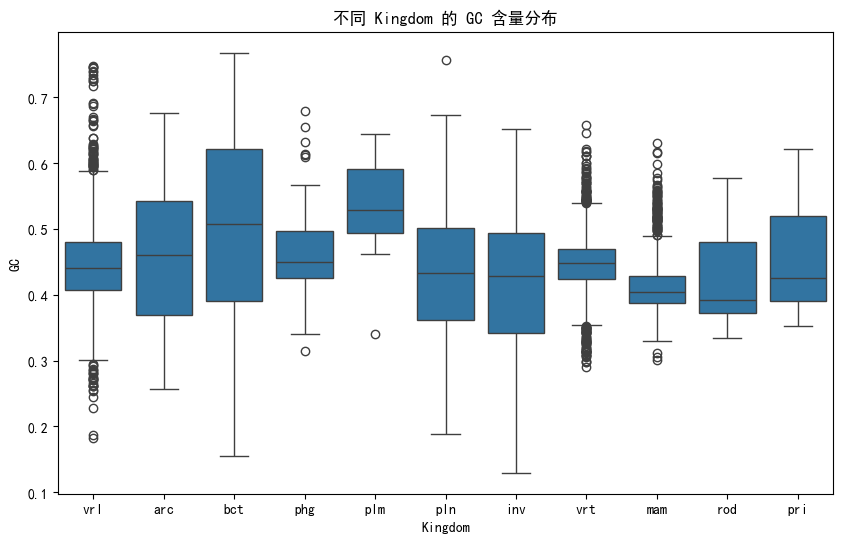

In [35]:
# 绘制GC含量分布图
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_with_codon, x='Kingdom', y='GC')
plt.title("不同 Kingdom 的 GC 含量分布")
plt.savefig(images_path+"GC_Content_In_Different_Kingdoms.png")
plt.show()

In [36]:
# 提取 64 个密码子频率列
p_codon = df.iloc[:, 7:]

# 标准化数据
scaler = StandardScaler()
p_codon_scaled = scaler.fit_transform(p_codon)

In [37]:
#pca_2 = PCA(n_components=2)
#p_conda_pca = pca_2.fit_transform(p_codon_scaled)

## 转换为 DataFrame
#pca_df = pd.DataFrame(data=p_conda_pca, columns=['PC1', 'PC2'])
#pca_df['Kingdom'] = df['Kingdom']

In [38]:
def Visual_Codon_Freq(n, type):
    from sklearn.decomposition import PCA

    # 执行 PCA
    pca = PCA(n_components=n)
    p_codon_pca = pca.fit_transform(p_codon_scaled)

    # 定义标题和文件名
    name_zh = f"PCA 可视化密码子频率（按 {type} 分类）"
    name_en = f"Visual_Codon_Freq_{type}.png"

    # 转换为 DataFrame
    pca_df = pd.DataFrame(data=p_codon_pca[:, :2], columns=['PC1', 'PC2'])
    pca_df[type] = df[type].values

    # 绘图
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=type, palette='Set2', s=50)
    plt.title(name_zh)
    plt.xlabel("主成分 1")
    plt.ylabel("主成分 2")
    plt.legend(title=type)
    plt.grid(True)
    plt.savefig(images_path + name_en)
    plt.show()

    print("各主成分贡献率（Kingdom）:")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"PC{i+1}: {var:.4f}")

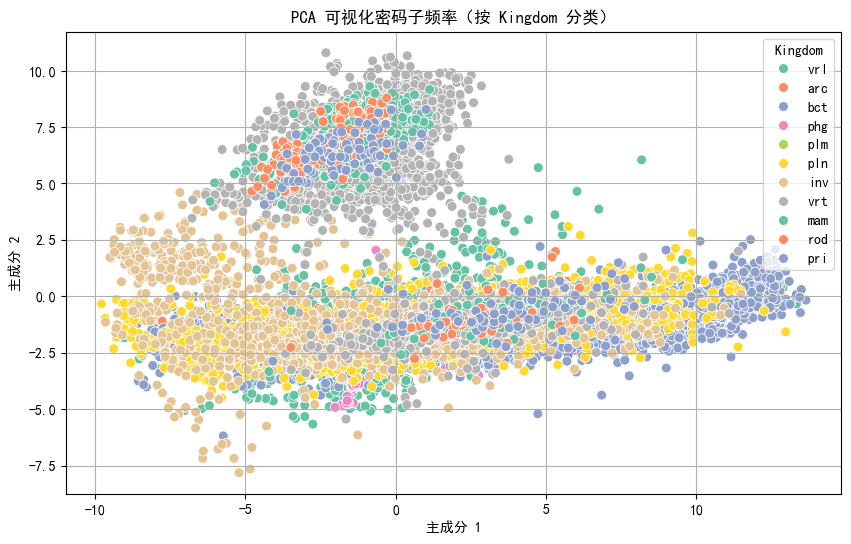

各主成分贡献率（Kingdom）:
PC1: 0.3079
PC2: 0.1835


In [39]:
Visual_Codon_Freq(2, "Kingdom")

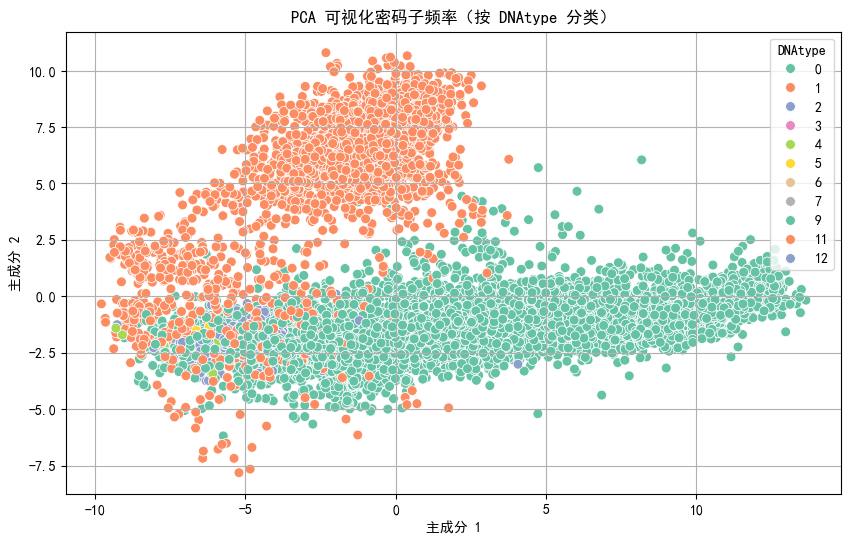

各主成分贡献率（Kingdom）:
PC1: 0.3079
PC2: 0.1835


In [40]:
Visual_Codon_Freq(2, "DNAtype")

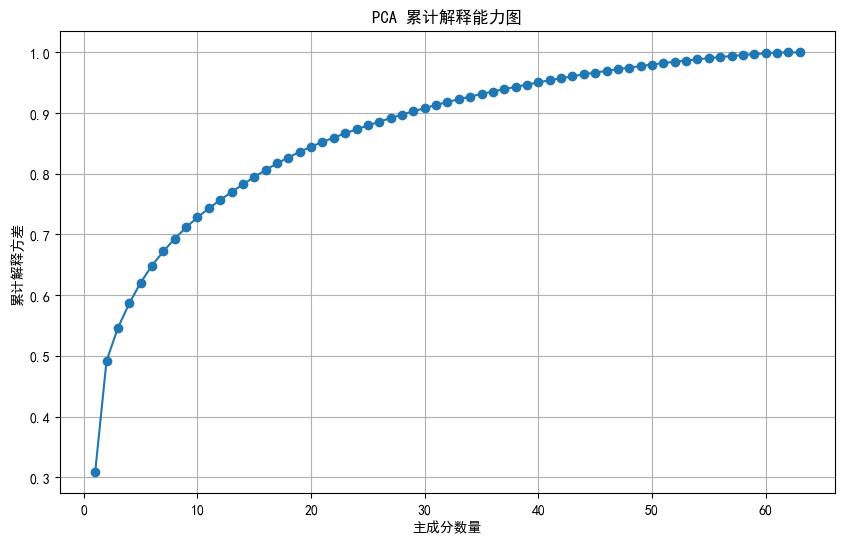

In [41]:
pca_full = PCA().fit(p_codon_scaled)
cumsum_var = pca_full.explained_variance_ratio_.cumsum()
num_components = len(cumsum_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_components + 1), cumsum_var, marker='o')
plt.xlabel("主成分数量")
plt.ylabel("累计解释方差")
plt.title("PCA 累计解释能力图")
plt.grid(True)
plt.show()

In [42]:
def Visual_Codon_Freq_3D(n, type):
    # 执行 PCA
    pca = PCA(n_components=n)
    p_codon_pca = pca.fit_transform(p_codon_scaled)

    # 提取前3个主成分
    pca_df = pd.DataFrame(data=p_codon_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
    pca_df[type] = df[type].values

    # 计算解释方差比例
    explained = pca.explained_variance_ratio_[:3]
    total_var = explained.sum()

    # 绘图
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 为每一类绘制散点
    unique_labels = pca_df[type].unique()
    colors = plt.cm.get_cmap('Set2', len(unique_labels))

    for idx, label in enumerate(unique_labels):
        subset = pca_df[pca_df[type] == label]
        ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                   label=label, color=colors(idx), s=40, alpha=0.8)

    ax.set_xlabel(f"PC1 ({explained[0]:.2%})")
    ax.set_ylabel(f"PC2 ({explained[1]:.2%})")
    ax.set_zlabel(f"PC3 ({explained[2]:.2%})")
    ax.set_title(f"PCA 三维可视化密码子频率（按 {type} 分类）\n前{n}主成分共解释 {total_var:.2%} 的方差")
    ax.legend(title=type)
    plt.tight_layout()

    # 保存图像
    filename = f"Visual_Codon_Freq_3D_{type}.png"
    plt.savefig(images_path + filename)
    plt.show()

C:\Users\bcg28\AppData\Local\Temp\ipykernel_31716\1903988109.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set2', len(unique_labels))


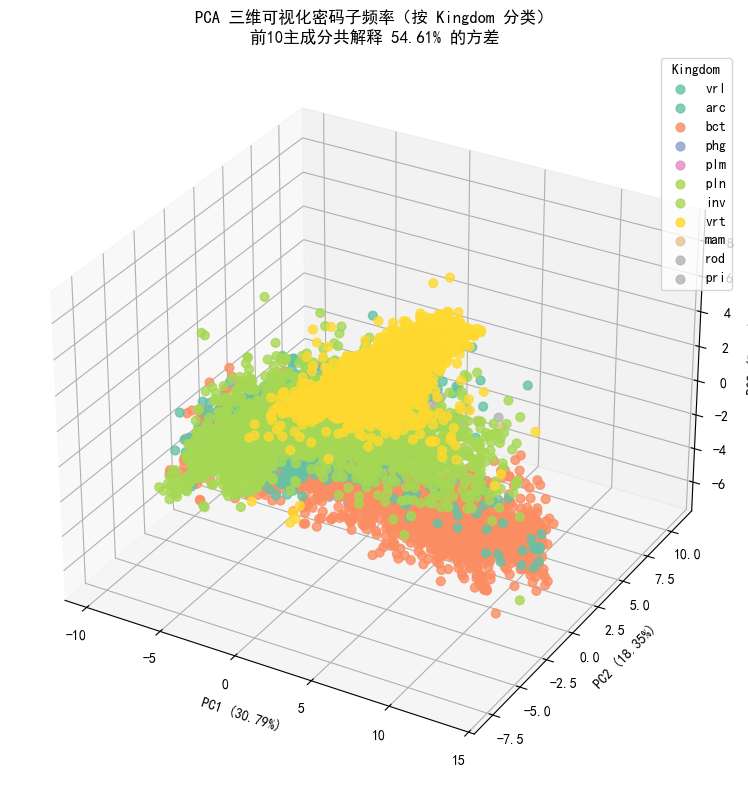

C:\Users\bcg28\AppData\Local\Temp\ipykernel_31716\1903988109.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set2', len(unique_labels))


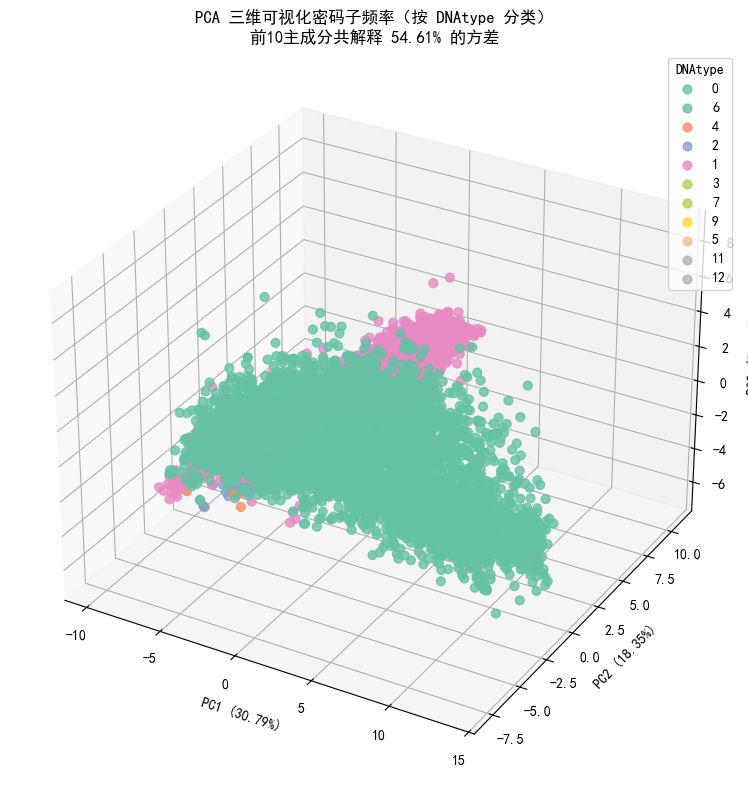

In [43]:
Visual_Codon_Freq_3D(10, "Kingdom")
Visual_Codon_Freq_3D(10, "DNAtype")